In [17]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
%reload_ext autoreload

In [19]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from time import time_ns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
print(f"Currently using {DEVICE}")

Currently using cuda


In [20]:
torch.manual_seed(0)

In [21]:
%autoreload

In [22]:
from src.data_import import *
train_loader, test_loader = load_olivetti(batch_size=BATCH_SIZE, shuffle=True)

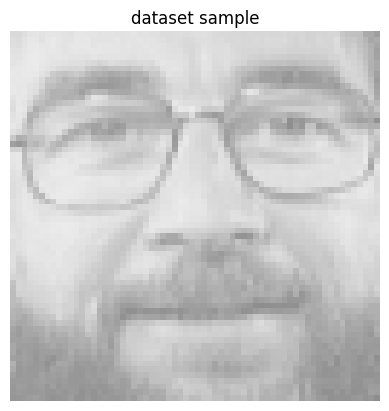

label: 27
shape: torch.Size([8, 1, 64, 64])


In [23]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="gray")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [24]:
n_heads = 3
IMAGE_SHAPE = (1, 64, 64)

In [25]:
from src.model import EBM, SmallEBM

model = SmallEBM(image_shape=IMAGE_SHAPE, n_heads=n_heads, batch_size=BATCH_SIZE)
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

SmallEBM(
  (heads): ModuleList(
    (0-2): 3 x SmallEnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
        (1): Flatten(start_dim=1, end_dim=-1)
        (2): GELU(approximate='none')
        (3): Linear(in_features=15376, out_features=32, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=32, out_features=1, bias=True)
      )
    )
  )
)

In [26]:
from src.sampler import ReplaySampler

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)

In [27]:
from src.information import TotalCorrelationEstimator

total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=16, lr=1e-3)
total_correlation_estimator.to(DEVICE)

In [28]:
# params = torch.load("./models/EBM_15_epochs_3_heads_(1, 64, 64)_shape_1782992338748688162t_OLIVETTI.pth")
# model = EBM(image_shape=(1, 64, 64), n_heads=3)
# model.load_state_dict(params)
# model.to(DEVICE)

In [29]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

In [30]:
epochs = 50
steps_per_epoch = len(train_loader)
warmup_steps = 100
total_steps = (epochs * steps_per_epoch) - warmup_steps
print(f"Steps={total_steps} -> Warmup={warmup_steps} + Rest={total_steps}")

Steps=1650 -> Warmup=100 + Rest=1650


In [31]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, betas=(0.000, 0.999))

# Warmup
warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)

# Decay
decay = CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps)
scheduler = SequentialLR(optimizer, schedulers=[warmup, decay], milestones=[warmup_steps])

In [32]:
from src.train import train_one_epoch_TC, train_one_epoch
#torch.autograd.set_detect_anomaly(True, check_nan=False)

for epoch in range(epochs):
    epoch_loss, _ = train_one_epoch_TC(
        # The essentials
        model, 
        sampler, 
        train_loader, 
        optimizer,

        # Sampler parameters
        sample_steps=30,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        tc_regularizations=0.2,
        
        # Stability
        scheduler=scheduler,
        clip_gradient=True,

        # TC regularization
        tc_estimator=total_correlation_estimator,
        
        # Device
        device=DEVICE,
        verbose=True
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")


100%|██████████| 35/35 [00:05<00:00,  6.18it/s]


  CD:     14.4752
  Reg:    28.6279
  Corr:   0.0013
  E_real: -0.5109
  E_fake: -14.9861
  Gap:    14.4752
Epoch 1, Loss: 43.1044


100%|██████████| 35/35 [00:06<00:00,  5.72it/s]


  CD:     -0.2914
  Reg:    0.5584
  Corr:   0.0207
  E_real: -1.0941
  E_fake: -0.8027
  Gap:    -0.2914
Epoch 2, Loss: 0.2876


100%|██████████| 35/35 [00:06<00:00,  5.55it/s]


...

  CD:     -0.0077
  Reg:    0.0003
  Corr:   0.0125
  E_real: -0.0099
  E_fake: -0.0022
  Gap:    -0.0077
Epoch 48, Loss: 0.0051


100%|██████████| 35/35 [00:05<00:00,  6.59it/s]


  CD:     -0.0025
  Reg:    0.0003
  Corr:   1.2718
  E_real: -0.0057
  E_fake: -0.0033
  Gap:    -0.0025
Epoch 49, Loss: 1.2696


100%|██████████| 35/35 [00:05<00:00,  5.87it/s]

  CD:     0.0003
  Reg:    0.0003
  Corr:   3.8059
  E_real: -0.0051
  E_fake: -0.0054
  Gap:    0.0003
Epoch 50, Loss: 3.8065


In [33]:
torch.save(model.state_dict(), f"./models/SmallEBM_{epoch}_epochs_{len(model.heads)}_heads_{IMAGE_SHAPE}_shape_{time_ns()}t_OLIVETTI_Weight_Decay.pth")

EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=-0.0040,  std=0.0143
  Test   →  mean=-0.0034,  std=0.0124
  |E_test - E_train| = 0.0007  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.0192,  std=0.0121
  Gap (E_real_train - E_fake) = 0.0151  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=6.9664,  std=0.1005
  Gap (E_real_train - E_noise) = -6.9704  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=-0.9365,  std=0.0049
  Head 1  →  mean=-0.2601,  std=0.0076
  Head 2  →  mean=1.1919,  std=0.0048
  Max off-diagonal correlation: 0.6576  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=0.5446,  std=0.1939,  min=-1.0000,  max=1.0000

[6] Visual samples (Langevin from noise)


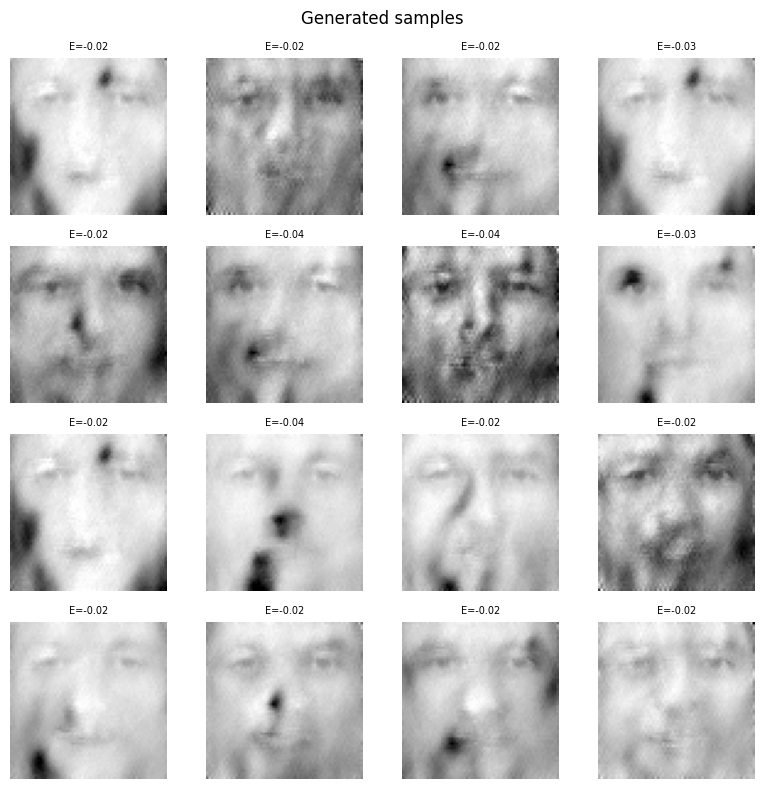


DONE


In [34]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [35]:
model.to(DEVICE)

SmallEBM(
  (heads): ModuleList(
    (0-2): 3 x SmallEnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
        (1): Flatten(start_dim=1, end_dim=-1)
        (2): GELU(approximate='none')
        (3): Linear(in_features=15376, out_features=32, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=32, out_features=1, bias=True)
      )
    )
  )
)

In [36]:
model.to(DEVICE)
samples = sampler.generate(10, steps=200, step_size=1.0, noise_std=0.005)

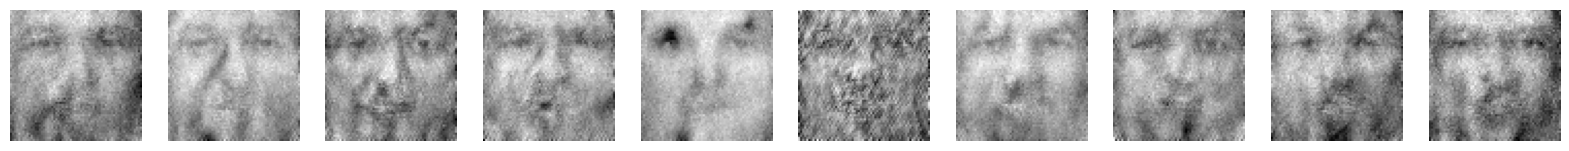

In [37]:
show_grid(samples, 10, cmap="gray")

In [38]:
# from src.plot import visualize_heads

# model.to("cpu")

# fig = visualize_heads(
#     model, 
#     steps=200, 
#     step_size=10.0, 
#     noise_std=0.01,
#     k=3,
#     cmap="Grays",
# )

# model.to(DEVICE)

In [39]:
# model = EBM(image_shape=(1,64,64), n_heads=3)
# mn = "EBM_20_epochs_(1, 64, 64)_shape_3_heads_1782902908565130435"
# f = "./models/olivetti/" + mn + ".pth"
# model.load_state_dict(torch.load(f))

In [40]:
from src.plot import visualize_head_gradients, visualize_head_abs_gradients

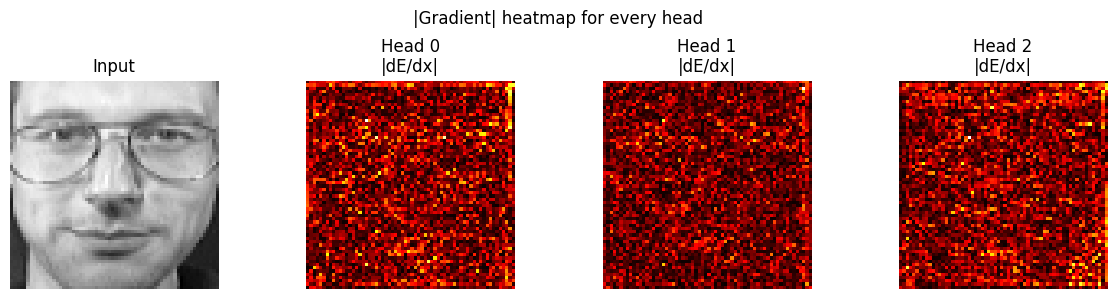

In [41]:
it = iter(test_loader)

for _ in range(0):
    it.__next__()
x0 = it.__next__()[0]

visualize_head_abs_gradients(model.to(DEVICE), x0, DEVICE)


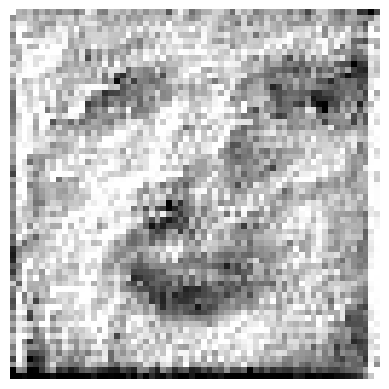

SmallEBM(
  (heads): ModuleList(
    (0-2): 3 x SmallEnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
        (1): Flatten(start_dim=1, end_dim=-1)
        (2): GELU(approximate='none')
        (3): Linear(in_features=15376, out_features=32, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=32, out_features=1, bias=True)
      )
    )
  )
)

In [45]:
from src.gradient_inspect import synthetize_image_from_head, synthetize_image

model.to("cpu")
class Combined(nn.Module):
    def __init__(self, m1, m2=None):
        super().__init__()
        self.m1 = m1
        self.m2 = m2
    def forward(self, x):
        if self.m2 is None:
            return self.m1(x)
        return self.m1(x) + self.m2(x)

combined = Combined(model.heads[1])
img, _ = synthetize_image_from_head(combined, n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)
show_single_sample(img, cmap="gray")

model.to(DEVICE)

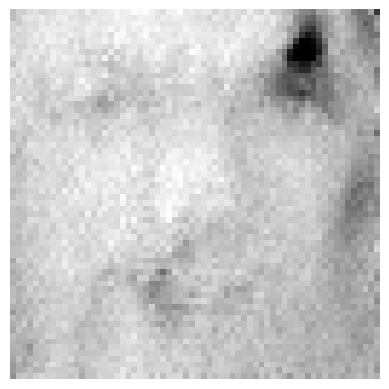

In [43]:
img, _ = synthetize_image(model.to("cpu"), img_dimension=IMAGE_SHAPE[-1], steps=5_000, step_size=1.0)
show_single_sample(img, cmap="gray")